# 07 - Perbandingan Semua Model

Menggabungkan hasil **K-Means** dan **DBSCAN** (masing-masing 3 ukuran jarak)
menjadi satu tabel perbandingan + visualisasi + waktu komputasi.

## Rumus Silhouette (pembanding utama)

$$s(i)=\frac{b(i)-a(i)}{\max\big(a(i),\,b(i)\big)},\qquad
S=\frac{1}{N}\sum_{i=1}^{N}s(i)$$

- $a(i)$ = jarak rata-rata ke titik lain **dalam klaster sendiri**
- $b(i)$ = jarak rata-rata ke klaster **tetangga terdekat**
- Nilai $S$ dari $-1$ sampai $1$; makin tinggi makin baik.

**Cara membandingkan yang adil:** nilai objektif tiap metrik beda satuan, jadi
pakai `Silhouette (Euclid)` (ruang jarak sama), Davies-Bouldin,
Calinski-Harabasz, waktu, dan **cakupan data** (100% - noise).

## 0. Import & Muat Hasil Semua Model

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

folder = 'Clustering_Stok'

In [2]:
files = sorted(glob.glob(f'{folder}/eval_*.csv'))
eval_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
eval_all['Cakupan Data (%)'] = 100 - eval_all['Noise (%)']
print('Model yang dibandingkan:', len(eval_all))

Model yang dibandingkan: 6


In [3]:
eval_all['Model'].tolist()

['DBSCAN-cosine',
 'DBSCAN-euclidean',
 'DBSCAN-manhattan',
 'KMeans-cosine',
 'KMeans-euclidean',
 'KMeans-manhattan']

## 1. Dataframe Perbandingan 6 Model

In [4]:
kolom = ['Model', 'Metrik', 'Parameter', 'Jumlah Klaster', 'Cakupan Data (%)',
         'Silhouette (Euclid)', 'Davies-Bouldin', 'Calinski-Harabasz', 'Waktu (s)']
tabel = eval_all[kolom].sort_values('Silhouette (Euclid)', ascending=False).reset_index(drop=True)
tabel.round(4)

,Model,Metrik,Parameter,Jumlah Klaster,Cakupan Data (%),Silhouette (Euclid),Davies-Bouldin,Calinski-Harabasz,Waktu (s)
0,KMeans-cosine,Cosine,k=3,3,100.00,0.2032,1.8103,62.12,0.0036
1,KMeans-manhattan,Manhattan (L1),k=3,3,100.00,0.1992,1.8298,60.79,0.0020
2,KMeans-euclidean,Euclidean (L2),k=4,4,100.00,0.1951,1.6581,55.22,0.0019
3,DBSCAN-manhattan,Manhattan (L1),"eps=4.0, min_samples=3",2,78.01,0.1816,0.9854,5.52,0.0021
4,DBSCAN-euclidean,Euclidean (L2),"eps=2.0, min_samples=3",2,85.46,0.1577,1.0197,5.07,0.0019
5,DBSCAN-cosine,Cosine,"eps=0.2, min_samples=3",3,90.78,0.0364,1.7802,31.59,0.0020


## 2. Visualisasi Perbandingan

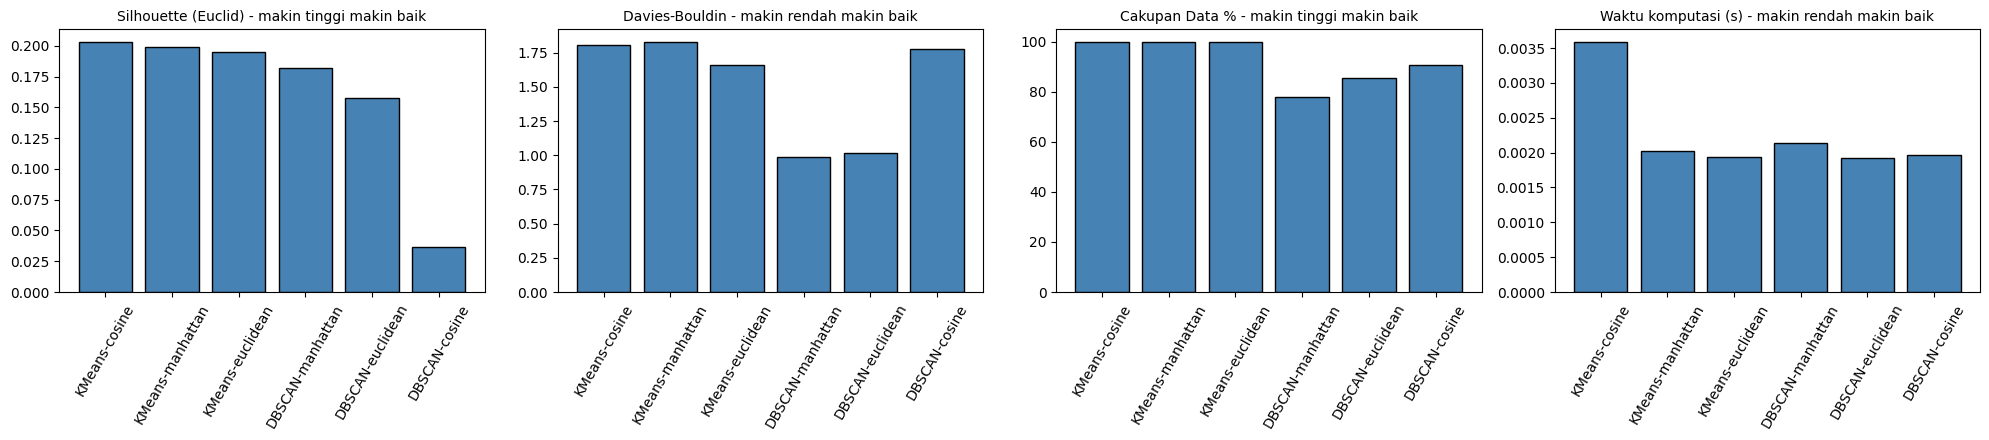

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, col, judul in zip(axes,
                          ['Silhouette (Euclid)', 'Davies-Bouldin', 'Cakupan Data (%)', 'Waktu (s)'],
                          ['Silhouette (Euclid) - makin tinggi makin baik',
                           'Davies-Bouldin - makin rendah makin baik',
                           'Cakupan Data % - makin tinggi makin baik',
                           'Waktu komputasi (s) - makin rendah makin baik']):
    ax.bar(tabel['Model'], tabel[col], color='steelblue', edgecolor='black')
    ax.set_title(judul, fontsize=10)
    ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

## 3. Ringkasan Otomatis

In [6]:
print('Silhouette (Euclid) tertinggi :', tabel.iloc[0]['Model'], f"({tabel.iloc[0]['Silhouette (Euclid)']:.3f})")
print('Davies-Bouldin terendah       :', tabel.loc[tabel['Davies-Bouldin'].idxmin(), 'Model'])
print('Paling cepat                  :', tabel.loc[tabel['Waktu (s)'].idxmin(), 'Model'], f"({tabel.loc[tabel['Waktu (s)'].idxmin(), 'Waktu (s)']:.4f}s)")
print('Rata-rata noise DBSCAN        :', f"{eval_all[eval_all['Algoritma'] == 'DBSCAN']['Noise (%)'].mean():.1f}%")

Silhouette (Euclid) tertinggi : KMeans-cosine (0.203)
Davies-Bouldin terendah       : DBSCAN-manhattan
Paling cepat                  : DBSCAN-euclidean (0.0019s)
Rata-rata noise DBSCAN        : 15.2%


## 4. Kerangka Analisis

| Aspek | K-Means | DBSCAN |
|---|---|---|
| Jumlah klaster | ditentukan (elbow) | otomatis dari kepadatan |
| Bentuk klaster | bulat/kompak | bebas bentuk |
| Outlier | masuk klaster terdekat | ditandai **noise** (-1) |
| Parameter | `k` | `eps`, `min_samples` |
| Cakupan data | 100% | < 100% |

**Poin kesimpulan:** (1) bandingkan skor **bersama cakupan data** - DBSCAN yang
skornya tinggi bisa jadi hanya menilai sebagian data; (2) Davies-Bouldin &
Calinski-Harabasz berbasis Euclidean sehingga cenderung menguntungkan K-Means
Euclidean; (3) Cosine biasanya paling lambat karena normalisasi vektor;
(4) pilih model sesuai kebutuhan: cakupan penuh (K-Means) vs deteksi produk
tidak biasa (DBSCAN).

## Kesimpulan

Tabel dan grafik di atas membandingkan 6 model secara adil. Gunakan
`Silhouette (Euclid)` + cakupan data + waktu untuk memilih model terbaik.